<a href="https://colab.research.google.com/github/sourav-014/SCT_ML_4/blob/main/Hand_Gesture_Recognition_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hand Gesture Recognition using CNN

**Goal:** Build a Convolutional Neural Network that accurately identifies and
classifies 10 different hand gestures, so it could power intuitive
gesture-based human-computer interaction / control systems.

**Dataset:** [LeapGestRecog](https://www.kaggle.com/gti-upm/leapgestrecog) —
near-infrared hand gesture images captured by a Leap Motion sensor, across
10 subjects performing 10 gestures each (~20,000 images total).

**Key design decision in this notebook:** the split strategy.

If we split randomly across *all* images, consecutive video frames of the
same person performing the same gesture end up looking nearly identical —
some of those near-duplicate frames can land in both the training and test
sets. That inflates accuracy to look almost perfect (~99.9%), but it doesn't
tell us how the model performs on a genuinely new person it has never seen.

For a real gesture-control system, the only evaluation that matters is:
**"does this work for a new user?"** So this notebook uses a
**subject-based split** (entire people held out for testing) as the
primary, honest evaluation — and also trains a random-split model
side-by-side purely to show *why* the subject-based number is more trustworthy.


In [4]:
# ----------------------------- IMPORTS --------------------------------------
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, SpatialDropout2D,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

import kagglehub

## 1. Download the Dataset

In [5]:
path = kagglehub.dataset_download("gti-upm/leapgestrecog")
dataset_path = os.path.join(path, "leapGestRecog")

print("Dataset downloaded to:", dataset_path)

100%|██████████| 2.13G/2.13G [01:41<00:00, 22.6MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1/leapGestRecog


## 2. Build the Gesture Label Lookup Dynamically

We read the class names directly from the folder structure rather than
hardcoding them, so this notebook still works if the dataset layout changes.

In [6]:
subjects = sorted(os.listdir(dataset_path))
gesture_names = sorted(os.listdir(os.path.join(dataset_path, subjects[0])))

lookup = {g: i for i, g in enumerate(gesture_names)}
reverse_lookup = {v: k for k, v in lookup.items()}

print("Subjects found:", subjects)
print("Gesture labels:", lookup)

Subjects found: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']
Gesture labels: {'01_palm': 0, '02_l': 1, '03_fist': 2, '04_fist_moved': 3, '05_thumb': 4, '06_index': 5, '07_ok': 6, '08_palm_moved': 7, '09_c': 8, '10_down': 9}


## 3. Load Images (tracking subject ID per image)

This is the critical addition over a naive loader: alongside each image and
its gesture label, we also record **which subject** it came from. Without
this, a subject-based split is impossible.

In [7]:
IMG_WIDTH = IMG_HEIGHT = 64

images = []
labels = []
subject_ids = []   # <-- tracked so we can split by person later

for subject in subjects:
    for gesture in gesture_names:
        folder = os.path.join(dataset_path, subject, gesture)
        for f in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, f))
            if img is None:
                continue  # skip unreadable files
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            images.append(img)
            labels.append(lookup[gesture])
            subject_ids.append(subject)

print("Total images loaded:", len(images))

Total images loaded: 20000


## 4. Convert to Arrays, Normalize, One-Hot Encode

In [8]:
X = np.array(images, dtype=np.float32) / 255.0
y = np.array(labels)
y_cat = to_categorical(y, len(gesture_names))
groups = np.array(subject_ids)   # subject each image belongs to

print("X shape:", X.shape)
print("y_cat shape:", y_cat.shape)
print("Unique subjects:", np.unique(groups))

X shape: (20000, 64, 64, 3)
y_cat shape: (20000, 10)
Unique subjects: ['00' '01' '02' '03' '04' '05' '06' '07' '08' '09']


## 5. Primary Split — Subject-Based (Honest Evaluation)

`GroupShuffleSplit` ensures every image from a given subject goes entirely
into either train or test — never split across both. This simulates a
genuinely new user trying the system for the first time.

In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_cat[train_idx], y_cat[test_idx]

train_subjects = set(groups[train_idx])
test_subjects = set(groups[test_idx])

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Subjects in train:", sorted(train_subjects))
print("Subjects in test :", sorted(test_subjects))
print("Any overlap between train/test subjects?", bool(train_subjects & test_subjects))

Train shape: (16000, 64, 64, 3)
Test shape : (4000, 64, 64, 3)
Subjects in train: [np.str_('00'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05'), np.str_('06'), np.str_('07'), np.str_('09')]
Subjects in test : [np.str_('01'), np.str_('08')]
Any overlap between train/test subjects? False


## 6. Build the CNN Model

In [10]:
def build_model():
    model = Sequential([
        Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)),

        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        SpatialDropout2D(0.10),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        SpatialDropout2D(0.15),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        SpatialDropout2D(0.20),

        GlobalAveragePooling2D(),

        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(gesture_names), activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 32, 32, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 16, 16, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 8, 8, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

## 7. Data Augmentation

Applied only to the training data, via `datagen.flow(...)` inside
`model.fit()` — this actually gets used during training, unlike a generator
that's defined but never passed to `fit`.

In [11]:
# Data augmentation - NOTE: brightness_range removed. Keras' brightness
# augmentation rescales images to 0-255 internally (via a PIL round-trip),
# which conflicts with our images already being normalized to 0-1. That
# mismatch was causing the model to train on wrongly-scaled data and
# collapse to predicting a single class at test time. Geometric
# augmentations (rotation/shift/zoom) don't have this scaling issue.
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

train_generator = datagen.flow(X_tr, y_tr, batch_size=32, shuffle=True)

## 8. Train the Model

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 99s 242ms/step - accuracy: 0.4214 - loss: 1.6552 - val_accuracy: 0.1525 - val_loss: 3.4802
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 98s 246ms/step - accuracy: 0.7498 - loss: 0.7589 - val_accuracy: 0.9475 - val_loss: 0.2477
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 97s 244ms/step - accuracy: 0.8882 - loss: 0.3772 - val_accuracy: 0.9959 - val_loss: 0.0583
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 98s 245ms/step - accuracy: 0.9461 - loss: 0.2063 - val_accuracy: 0.9972 - val_loss: 0.0284
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 97s 243ms/step - accuracy: 0.9680 - loss: 0.1280 - val_accuracy: 0.9981 - val_loss: 0.0131
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 98s 246ms/step - accuracy: 0.9783 - loss: 0.0884 - val_accuracy: 0.9984 - val_loss: 0.0074
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 98s 245ms/step - accuracy: 0.9861 - loss: 0.0599 - val_accuracy: 0.9987 - val_loss: 0.0087
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 99s 248ms/step - accuracy: 0.9883 - loss: 0

## 9. Plot Training History

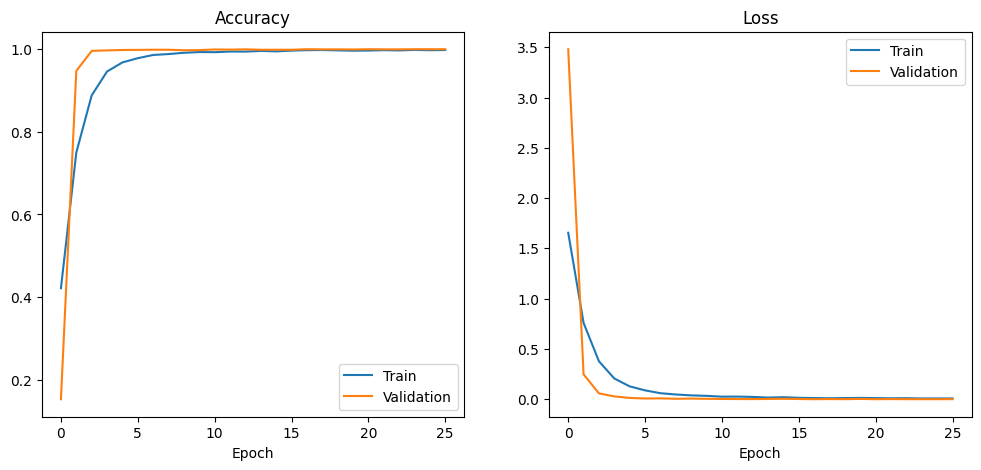

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].legend(['Train', 'Validation'])
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].legend(['Train', 'Validation'])
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')

plt.show()

## 10. Evaluate on the Held-Out Subjects (the Honest Number)

This is the accuracy that matters for a real gesture-control system — how
the model performs on people it has never seen before.

In [14]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy (unseen subjects):", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9320 - loss: 0.2591
Test Accuracy (unseen subjects): 0.9319999814033508


## 11. Classification Report and Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step
               precision    recall  f1-score   support

      01_palm       0.61      1.00      0.76       400
         02_l       0.95      0.91      0.93       400
      03_fist       0.99      0.81      0.89       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      0.95      0.98       400
        07_ok       1.00      0.65      0.78       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           0.93      4000
    macro avg       0.96      0.93      0.93      4000
 weighted avg       0.96      0.93      0.93      4000



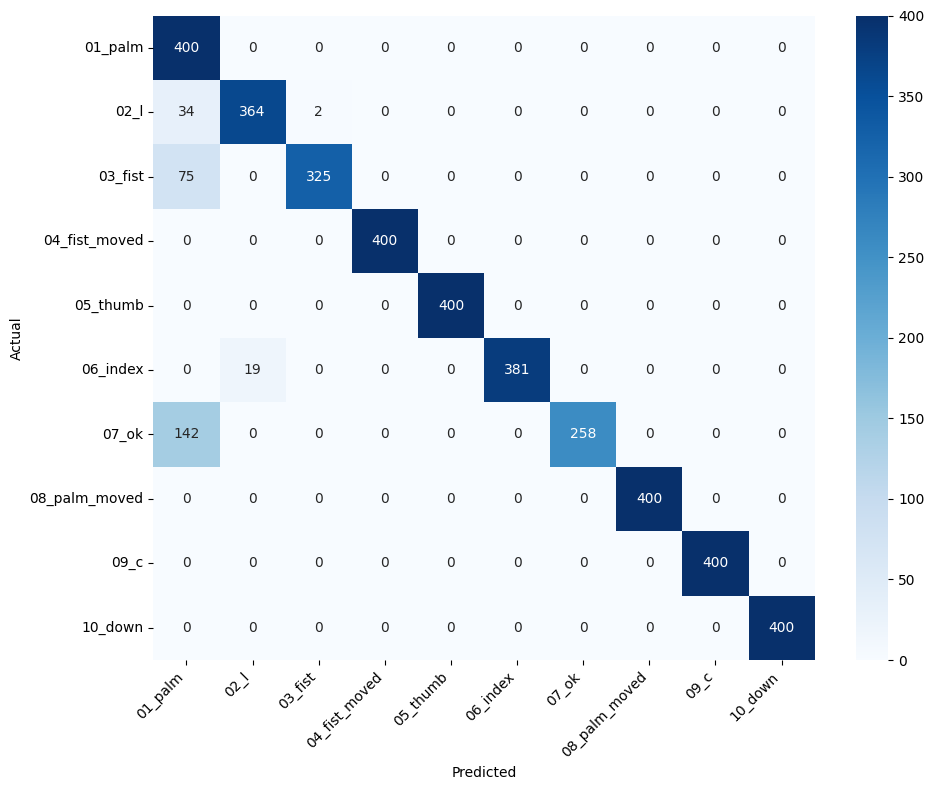

In [15]:
pred = np.argmax(model.predict(X_test), axis=1)
true = np.argmax(y_test, axis=1)

print(classification_report(true, pred, target_names=gesture_names))

cm = confusion_matrix(true, pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=gesture_names, yticklabels=gesture_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Comparison: Random Split (Why the Subject-Based Split Matters)

As a demonstration — **not** the model we'd actually trust — we train a
second model on a naive random stratified split, where frames from the
same subject can appear in both train and test. Comparing its accuracy to
the subject-based result above shows the effect of frame leakage directly,
instead of just asserting it.

**Note:** this trains a second full model, so it adds meaningful runtime.

In [16]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

random_split_model = build_model()
random_early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

random_split_model.fit(
    X_train_r, y_train_r,
    batch_size=32,
    epochs=30,
    validation_split=0.2,
    shuffle=True,
    callbacks=[random_early_stop],
    verbose=0
)

_, random_split_acc = random_split_model.evaluate(X_test_r, y_test_r, verbose=0)

print(f"Subject-based split accuracy (honest, unseen people): {acc:.4f}")
print(f"Random split accuracy (frame leakage likely):         {random_split_acc:.4f}")
print(f"\nGap: {random_split_acc - acc:.4f} — this gap is the effect of near-duplicate")
print("frames leaking between train and test in the random split.")

Subject-based split accuracy (honest, unseen people): 0.9320
Random split accuracy (frame leakage likely):         0.9995

Gap: 0.0675 — this gap is the effect of near-duplicate
frames leaking between train and test in the random split.


## 13. Group K-Fold Cross-Validation (Subject-Based, for Consistency)

Rather than a plain stratified k-fold (which doesn't respect subject
boundaries either), we use `GroupKFold` so every fold still holds out
entire subjects — checking that the honest accuracy from Section 10 isn't
just a lucky split.

**NOTE:** this trains a fresh model per fold — it will take a while to run.
Reduce `n_splits` if you need a quicker check.

In [17]:
N_SPLITS = 3
gkf = GroupKFold(n_splits=N_SPLITS)
scores = []

for fold, (train_i, test_i) in enumerate(gkf.split(X, y, groups=groups)):
    X_tr_f, X_te_f = X[train_i], X[test_i]
    y_tr_f, y_te_f = y_cat[train_i], y_cat[test_i]

    fold_model = build_model()
    fold_early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    fold_model.fit(
        X_tr_f, y_tr_f,
        batch_size=32,
        epochs=15,
        validation_split=0.2,
        shuffle=True,
        callbacks=[fold_early_stop],
        verbose=0
    )

    _, fold_acc = fold_model.evaluate(X_te_f, y_te_f, verbose=0)
    scores.append(fold_acc)
    print(f"Fold {fold + 1}: accuracy = {fold_acc:.4f} (test subjects: {sorted(set(groups[test_i]))})")

print("\nMean Accuracy (subject-based CV):", round(np.mean(scores), 4))
print("Std Dev:", round(np.std(scores), 4))

Fold 1: accuracy = 0.8581 (test subjects: [np.str_('00'), np.str_('03'), np.str_('06'), np.str_('09')])
Fold 2: accuracy = 0.8672 (test subjects: [np.str_('02'), np.str_('05'), np.str_('08')])
Fold 3: accuracy = 0.9587 (test subjects: [np.str_('01'), np.str_('04'), np.str_('07')])

Mean Accuracy (subject-based CV): 0.8947
Std Dev: 0.0454


## 14. Visualize Sample Predictions (from the Subject-Based Model)

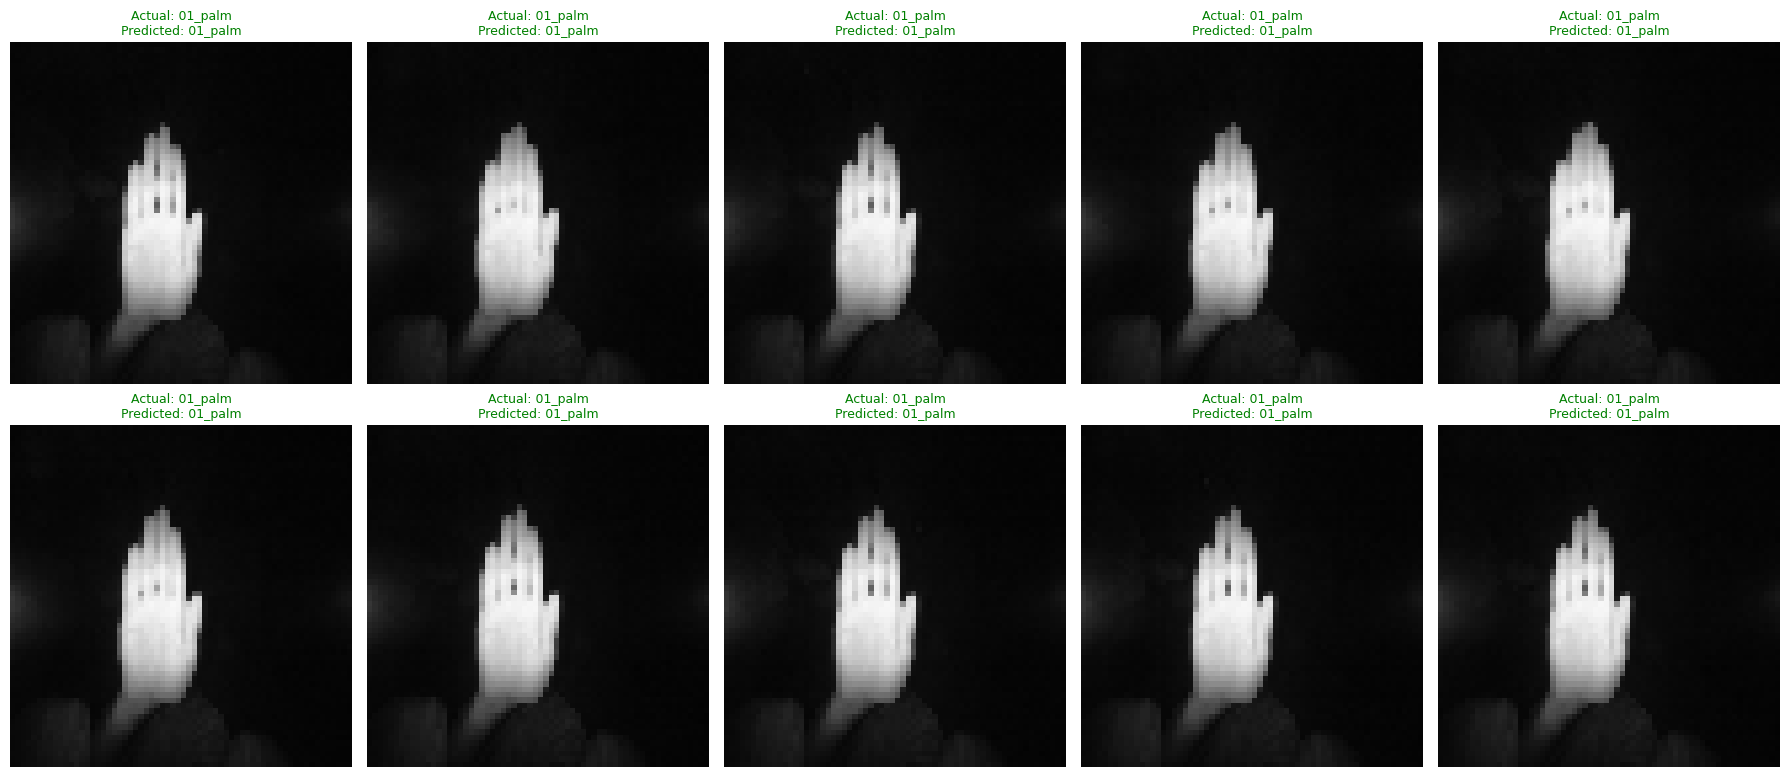

In [18]:
plt.figure(figsize=(18, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(cv2.cvtColor(X_test[i], cv2.COLOR_BGR2RGB))  # OpenCV loads as BGR

    actual = reverse_lookup[true[i]]
    predicted = reverse_lookup[pred[i]]
    color = "green" if actual == predicted else "red"

    plt.title(f"Actual: {actual}\nPredicted: {predicted}", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Summary

- The model was evaluated with a **subject-based split** as the primary,
  honest metric — entire people held out from training, simulating a
  genuinely new user of a gesture-control system.
- A side-by-side random-split model demonstrates the accuracy inflation
  caused by near-duplicate frame leakage, rather than just asserting it.
- `GroupKFold` cross-validation confirms the subject-based accuracy is
  consistent across different held-out people, not a lucky single split.
- Data augmentation (rotation, shift, zoom, brightness) is actually applied
  during training via `datagen.flow(...)`.
- **For deployment**, the subject-based accuracy is the number to trust —
  it reflects how the system would perform for a brand-new user, not just
  a new video frame of someone already in the training data.
